In [1]:
%cd ..

C:\Users\daanw\PycharmProjects\BSc-Thesis


In [2]:
import os
import torch
from torchvision.transforms import transforms
from project.models import EDMCallum
from project.util.device import get_available_acc
from project.util.plotting import plot_sample
from project.util.data import ReplayMemoryData

In [3]:
PATH = os.path.join("checkpoints", "diff", "ArchSimple.pt")
DATA = os.path.join("checkpoints", "memory", "BreakoutDDQNAdamW.pt")

In [4]:
device = get_available_acc()
device

'cuda'

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5),
    transforms.Pad(2),
])

In [6]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=1_000
)

In [40]:
x = data[211].to(device)

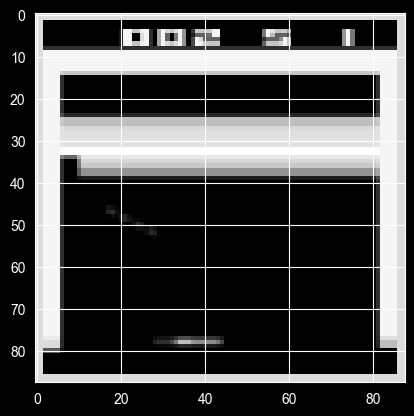

In [41]:
plot_sample(x)

In [42]:
mask = torch.ones_like(x, device=device)
mask[:, :9, :] = 0

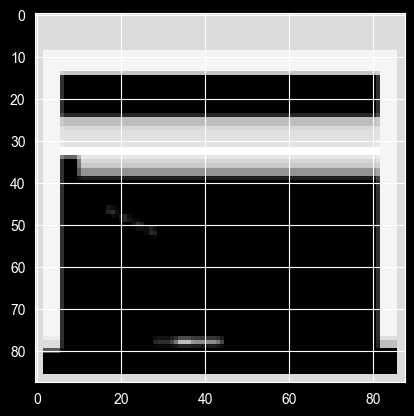

In [43]:
plot_sample(x * mask)

In [44]:
model = EDMCallum.from_checkpoint(PATH, device, U=3).to(device)

100%|██████████| 32/32 [00:05<00:00,  6.08it/s]


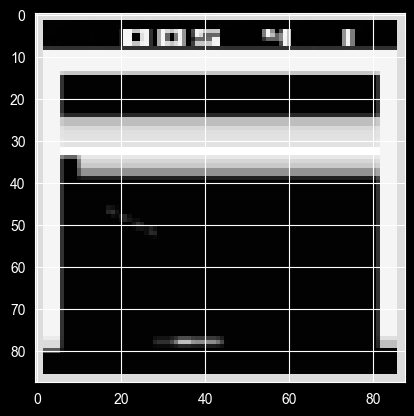

In [45]:
x_inpainted = model.inpaint(x.unsqueeze(0), mask)
plot_sample(x_inpainted.squeeze())